In [3]:
import requests
import pandas as pd
import time
import logging

# logging
logging.basicConfig(
    filename="nba_scraper.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)
# website to scrape
url = "https://stats.nba.com/stats/leaguedashplayerstats"
# headers for user-agent
headers = {
    "User-Agent": "Mozilla/5.0",
    "Referer": "https://www.nba.com/",
    "Accept": "application/json, text/plain, */*"
}

#  creating list of all seasons 2020-21 → 2024-25
seasons = [f"{year}-{str(year+1)[-2:]}" for year in range(2020, 2025)]

all_data = []

for season in seasons:
    logging.info(f"Starting season {season}")
    print(f"Processing {season}...")

    params = {
        "Season": season,
        "SeasonType": "Regular Season",
        "PerMode": "PerGame",
        "LeagueID": "00"
    }

    for attempt in range(3):
        try:
            response = requests.get(url, headers=headers, params=params, timeout=10)
            response.raise_for_status()

            data = response.json()

            # converting to DataFrame
            headers_data = data['resultSets'][0]['headers']
            rows = data['resultSets'][0]['rowSet']

            df = pd.DataFrame(rows, columns=headers_data)
            df['SEASON'] = season  # adding new season

            all_data.append(df)

            logging.info(f"Season {season} loaded: {len(df)} rows")
            print(f"{season} done")

            time.sleep(1)  # rate limiting
            break

        except requests.exceptions.RequestException as e:
            logging.error(f"{season} attempt {attempt+1} failed: {e}")
            print(f"Error on {season}, attempt {attempt+1}")
            time.sleep(2)

# joining all tables
df_raw = pd.concat(all_data, ignore_index=True)

# saving
df_raw.to_csv("nba_raw_data_2000_2025.csv", index=False)

print("All seasons collected!")
print("Shape:", df_raw.shape)

In [2]:
import pandas as pd
import time
import logging
from nba_api.stats.endpoints import leaguedashplayerstats

# ---------------- LOGGING ----------------
logging.basicConfig(
    filename="scraper.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

# ---------------- CONFIG ----------------
seasons = ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25']
all_data = []

# ---------------- SCRAPING ----------------
for season in seasons:
    try:
        logging.info(f"Starting season {season}")

        stats = leaguedashplayerstats.LeagueDashPlayerStats(
            season=season,
            per_mode_detailed='PerGame'
        )

        df = stats.get_data_frames()[0]
        df['SEASON'] = season

        all_data.append(df)

        logging.info(f"Success {season} | rows: {len(df)}")

        time.sleep(1.5)  # rate limiting

    except Exception as e:
        logging.error(f"Error in season {season}: {e}")

# ---------------- SAVE RAW DATA ----------------
df_raw = pd.concat(all_data, ignore_index=True)

df_raw.to_csv("nba_raw_data.csv", index=False)

logging.info(f"Saved dataset with {len(df_raw)} rows")

In [3]:
# ---------------- CHECKING RAW DATA ----------------
print(df_raw.columns)
# ---------------- CHOOSING ONLY USEFUL COLUMNS ----------------
df = df_raw[[
    'PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM',
    'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT',
    'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS',
    'DD2', 'TD3', 'SEASON']]

Index(['PLAYER_ID', 'PLAYER_NAME', 'NICKNAME', 'TEAM_ID', 'TEAM_ABBREVIATION',
       'AGE', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M',
       'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST',
       'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS',
       'NBA_FANTASY_PTS', 'DD2', 'TD3', 'WNBA_FANTASY_PTS', 'GP_RANK',
       'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK',
       'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK',
       'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK',
       'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK',
       'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK', 'NBA_FANTASY_PTS_RANK',
       'DD2_RANK', 'TD3_RANK', 'WNBA_FANTASY_PTS_RANK', 'TEAM_COUNT',
       'SEASON'],
      dtype='str')


In [4]:
# ---------------- STRUCTURE OF RAW DATA ----------------
print(df_raw.head())

   PLAYER_ID    PLAYER_NAME NICKNAME     TEAM_ID TEAM_ABBREVIATION   AGE  GP  \
0     203932   Aaron Gordon    Aaron  1610612743               DEN  25.0  50   
1    1628988  Aaron Holiday    Aaron  1610612754               IND  24.0  66   
2    1630174  Aaron Nesmith    Aaron  1610612738               BOS  21.0  46   
3    1627846    Abdel Nader    Abdel  1610612756               PHX  27.0  24   
4    1629690    Adam Mokoka     Adam  1610612741               CHI  22.0  14   

    W   L  W_PCT  ...  PF_RANK  PFD_RANK  PTS_RANK  PLUS_MINUS_RANK  \
0  29  21  0.580  ...      228        79       136              139   
1  30  36  0.455  ...      335       283       276              228   
2  22  24  0.478  ...      198       411       382              250   
3  16   8  0.667  ...      341       216       302              143   
4   3  11  0.214  ...      518       524       518              280   

   NBA_FANTASY_PTS_RANK  DD2_RANK  TD3_RANK  WNBA_FANTASY_PTS_RANK  \
0                   11

In [5]:
# ---------------- HANDLING MISSING VALUES ----------------
print(df.isnull().sum())

PLAYER_NAME          0
TEAM_ABBREVIATION    0
AGE                  0
GP                   0
W                    0
L                    0
W_PCT                0
MIN                  0
FGM                  0
FGA                  0
FG_PCT               0
FG3M                 0
FG3A                 0
FG3_PCT              0
FTM                  0
FTA                  0
FT_PCT               0
REB                  0
AST                  0
TOV                  0
STL                  0
BLK                  0
BLKA                 0
PF                   0
PFD                  0
PTS                  0
PLUS_MINUS           0
DD2                  0
TD3                  0
SEASON               0
dtype: int64


In [6]:
# ---------------- HANDLING DUPLICATED ROWS ----------------
print(df.duplicated(subset=['PLAYER_NAME', 'SEASON']).sum())

0


In [7]:
# ---------------- INSPECTING DATA TYPES ----------------
print(df.dtypes)

PLAYER_NAME              str
TEAM_ABBREVIATION        str
AGE                  float64
GP                     int64
W                      int64
L                      int64
W_PCT                float64
MIN                  float64
FGM                  float64
FGA                  float64
FG_PCT               float64
FG3M                 float64
FG3A                 float64
FG3_PCT              float64
FTM                  float64
FTA                  float64
FT_PCT               float64
REB                  float64
AST                  float64
TOV                  float64
STL                  float64
BLK                  float64
BLKA                 float64
PF                   float64
PFD                  float64
PTS                  float64
PLUS_MINUS           float64
DD2                    int64
TD3                    int64
SEASON                   str
dtype: object


In [8]:
# ---------------- OUTLIERS CHECKING ----------------
Q1 = df['PTS'].quantile(0.25)
Q3 = df['PTS'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['PTS'] > upper)]

print(outliers)

            PLAYER_NAME TEAM_ABBREVIATION   AGE  GP   W   L  W_PCT   MIN  \
45         Bradley Beal               WAS  28.0  60  32  28  0.533  35.8   
86        Collin Sexton               CLE  22.0  60  18  42  0.300  35.3   
95       Damian Lillard               POR  30.0  67  39  28  0.582  35.8   
111        De'Aaron Fox               SAC  23.0  58  24  34  0.414  35.1   
132        Devin Booker               PHX  24.0  67  48  19  0.716  33.9   
...                 ...               ...   ...  ..  ..  ..    ...   ...   
2754      Stephen Curry               GSW  37.0  70  41  29  0.586  32.2   
2779         Trae Young               ATL  26.0  76  36  40  0.474  36.0   
2801       Tyrese Maxey               PHI  24.0  52  20  32  0.385  37.7   
2806  Victor Wembanyama               SAS  21.0  46  21  25  0.457  33.2   
2823    Zion Williamson               NOP  24.0  30  10  20  0.333  28.6   

       FGM   FGA  ...  STL  BLK  BLKA   PF  PFD   PTS  PLUS_MINUS  DD2  TD3  \
45    11

In [9]:
# ---------------- CREATING NEW FEATURES ----------------
# Points efficiency per minute
df['PTS_PER_MIN'] = df['PTS']/df['MIN']
# Combined efficiency score
df['EFF'] = (df['PTS'] + df['REB'] + df['AST'] - df['TOV']) / df['MIN']
# Total shot volume per game
df['SHOT_VOLUME'] = df['FGA'] + df['FTA']

In [10]:
# ---------------- CHECKING AFTER ALL STEPS ----------------
print(df.head())

     PLAYER_NAME TEAM_ABBREVIATION   AGE  GP   W   L  W_PCT   MIN  FGM   FGA  \
0   Aaron Gordon               DEN  25.0  50  29  21  0.580  27.7  4.6  10.0   
1  Aaron Holiday               IND  24.0  66  30  36  0.455  17.8  2.6   6.6   
2  Aaron Nesmith               BOS  21.0  46  22  24  0.478  14.5  1.7   3.9   
3    Abdel Nader               PHX  27.0  24  16   8  0.667  14.8  2.4   4.8   
4    Adam Mokoka               CHI  22.0  14   3  11  0.214   4.0  0.5   1.4   

   ...   PF  PFD   PTS  PLUS_MINUS  DD2  TD3   SEASON  PTS_PER_MIN       EFF  \
0  ...  1.8  2.7  12.4         1.2    3    1  2020-21     0.447653  0.700361   
1  ...  1.4  1.1   7.2         0.0    1    0  2020-21     0.404494  0.528090   
2  ...  1.9  0.6   4.7        -0.2    0    0  2020-21     0.324138  0.517241   
3  ...  1.4  1.5   6.7         1.2    0    0  2020-21     0.452703  0.628378   
4  ...  0.4  0.1   1.1        -0.6    0    0  2020-21     0.275000  0.375000   

   SHOT_VOLUME  
0         13.0  
1   

In [11]:
# ---------------- SAVE CLEAN DATA ----------------
df.to_csv("nba_clean_data.csv", index=False)

In [12]:
# ---------------- DESCRIPTIVE STATISTICS ----------------
key_cols = ['PTS', 'AST', 'REB', 'STL', 'BLK', 'FG_PCT', 'MIN', 'PLUS_MINUS']
df[key_cols].describe().round(2)

,PTS,AST,REB,STL,BLK,FG_PCT,MIN,PLUS_MINUS
count,2825.00,2825.00,2825.00,2825.00,2825.00,2825.00,2825.00,2825.00
mean,8.71,2.00,3.52,0.62,0.39,0.45,19.31,-0.46
std,6.61,1.86,2.40,0.40,0.40,0.12,9.62,3.34
min,0.00,0.00,0.00,0.00,0.00,0.00,0.40,-30.70
25%,3.80,0.70,1.80,0.30,0.10,0.40,11.60,-2.20
50%,7.00,1.40,3.10,0.60,0.30,0.45,18.90,-0.40
75%,11.90,2.70,4.60,0.90,0.50,0.50,27.40,1.40
max,34.70,11.70,14.70,3.00,3.80,1.00,43.50,14.00


In [13]:
# ---------------- IMPORT LIBRARIES FOR NEXT STEP ----------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from scipy import stats
import os

sns.set_theme(style="whitegrid")

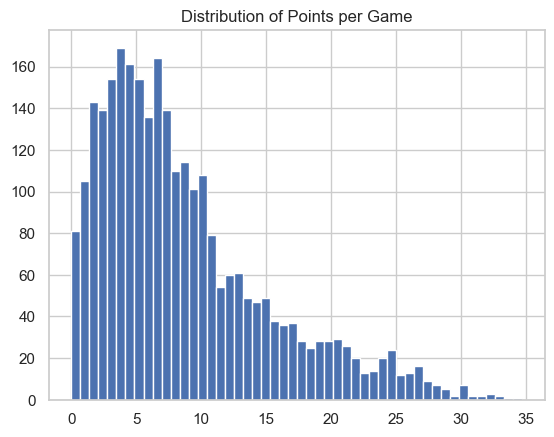

In [14]:
# ---------------- DISTRIBUTION OF POINTS ----------------
df['PTS'].hist(bins=50)
plt.title("Distribution of Points per Game")
plt.show()

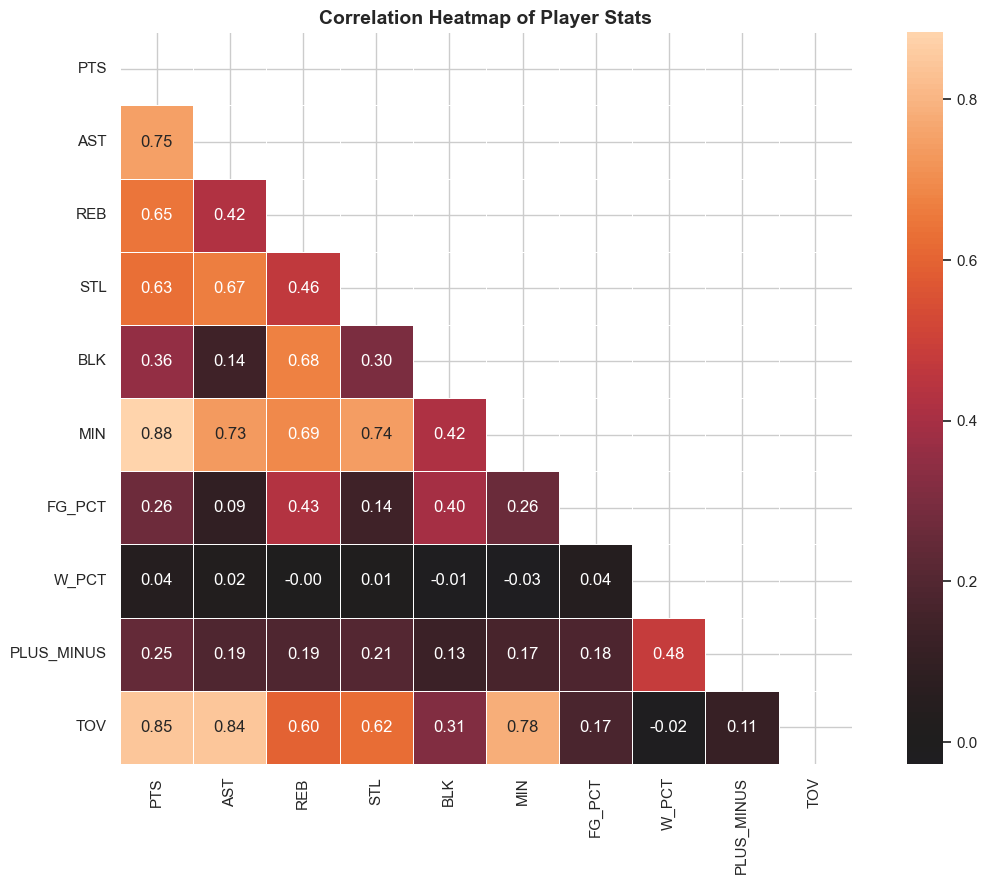

In [15]:
# ---------------- CORRELATION HEAT MAP ----------------
corr_cols = ['PTS', 'AST', 'REB', 'STL', 'BLK', 'MIN', 'FG_PCT', 'W_PCT', 'PLUS_MINUS', 'TOV']
corr = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Player Stats', fontsize=14, fontweight='bold')
plt.tight_layout()
os.makedirs('charts', exist_ok=True)
plt.savefig('charts/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ---------------- AVERAGE POINTS OF PLAYERS BY TEAMS ----------------
df.groupby('TEAM_ABBREVIATION')['PTS'].mean().sort_values(ascending=False)

TEAM_ABBREVIATION
BKN    9.433684
LAC    9.240449
NOP    9.185870
ATL    9.095699
HOU    9.065909
POR    9.058163
MIA    8.976842
CHA    8.958511
OKC    8.885567
GSW    8.872941
PHI    8.846602
IND    8.836842
MEM    8.819192
PHX    8.818681
MIL    8.777660
LAL    8.763158
DEN    8.685393
TOR    8.676531
UTA    8.646237
DAL    8.604167
BOS    8.497849
SAS    8.454348
ORL    8.447368
CLE    8.420833
MIN    8.369318
CHI    8.334783
DET    8.261165
NYK    8.250549
WAS    8.244330
SAC    7.860606
Name: PTS, dtype: float64

In [17]:
# ---------------- DISTRIBUTION OF PLAYER'S AGE ----------------
df.groupby('AGE')['PTS'].mean()

AGE
19.0     7.476000
20.0     7.055462
21.0     7.341304
22.0     8.163319
23.0     8.396416
24.0     7.559412
25.0     7.878231
26.0     8.892704
27.0     9.494258
28.0     9.413559
29.0     9.989474
30.0    10.683333
31.0    10.033636
32.0    10.813684
33.0    11.067123
34.0    10.233962
35.0     9.333333
36.0     8.400000
37.0     8.227273
38.0     7.975000
39.0     6.900000
40.0     9.775000
41.0     3.000000
42.0     2.500000
43.0     3.900000
Name: PTS, dtype: float64

In [18]:
# ---------------- TOP 10 PLAYERS BY POINTS PER GAME ----------------
df[df['GP'] > 60] \
    .sort_values('PTS', ascending=False) \
    .head(10)

,PLAYER_NAME,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,MIN,FGM,FGA,...,PF,PFD,PTS,PLUS_MINUS,DD2,TD3,SEASON,PTS_PER_MIN,EFF,SHOT_VOLUME
2056,Luka Dončić,DAL,25.0,70,46,24,0.657,37.5,11.5,23.6,...,2.1,6.8,33.9,4.6,49,21,2023-24,0.904000,1.304000,32.3
1396,Joel Embiid,PHI,29.0,66,43,23,0.652,34.6,11.0,20.1,...,3.1,7.7,33.1,6.4,39,1,2022-23,0.956647,1.274566,31.8
2746,Shai Gilgeous-Alexander,OKC,26.0,76,63,13,0.829,34.2,11.3,21.8,...,2.2,6.1,32.7,12.1,6,0,2024-25,0.956140,1.219298,30.6
1485,Luka Dončić,DAL,24.0,66,33,33,0.500,36.2,10.9,22.0,...,2.5,7.3,32.4,1.9,36,10,2022-23,0.895028,1.254144,32.5
470,Stephen Curry,GSW,33.0,63,37,26,0.587,34.2,10.4,21.7,...,1.9,4.6,32.0,3.9,8,0,2020-21,0.935673,1.166667,28.0
1608,Shai Gilgeous-Alexander,OKC,24.0,68,33,35,0.485,35.5,10.4,20.3,...,2.8,7.2,31.4,2.2,3,0,2022-23,0.884507,1.095775,31.2
1311,Giannis Antetokounmpo,MIL,28.0,63,47,16,0.746,32.1,11.2,20.3,...,3.1,9.0,31.1,5.4,46,6,2022-23,0.968847,1.392523,32.6
835,Joel Embiid,PHI,28.0,68,45,23,0.662,33.8,9.8,19.6,...,2.7,8.5,30.6,5.4,46,2,2021-22,0.905325,1.284024,31.4
1868,Giannis Antetokounmpo,MIL,29.0,73,45,28,0.616,35.2,11.5,18.8,...,2.9,8.3,30.4,4.6,57,10,2023-24,0.863636,1.278409,29.5
2436,Giannis Antetokounmpo,MIL,30.0,67,40,27,0.597,34.2,11.8,19.7,...,2.3,7.6,30.4,5.0,55,11,2024-25,0.888889,1.336257,30.3


In [19]:
# ---------------- BOTTOM 10 PLAYERS BY POINTS PER GAME ----------------
df[df['GP'] > 60] \
    .sort_values('PTS') \
    .head(10)

,PLAYER_NAME,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,MIN,FGM,FGA,...,PF,PFD,PTS,PLUS_MINUS,DD2,TD3,SEASON,PTS_PER_MIN,EFF,SHOT_VOLUME
1661,Usman Garuba,HOU,21.0,75,21,54,0.280,12.9,1.1,2.4,...,1.8,0.6,3.0,-3.4,0,0,2022-23,0.232558,0.573643,3.0
646,Dalano Banton,TOR,22.0,64,37,27,0.578,10.9,1.3,3.2,...,1.1,0.6,3.2,0.5,0,0,2021-22,0.293578,0.532110,3.9
1899,JT Thor,CHA,21.0,63,16,47,0.254,12.4,1.3,2.9,...,1.0,0.3,3.2,-0.8,0,0,2023-24,0.258065,0.467742,3.2
1846,Dwight Powell,DAL,32.0,63,38,25,0.603,13.3,1.1,1.7,...,1.8,1.7,3.3,0.0,1,0,2023-24,0.248120,0.563910,3.1
2279,Andre Jackson Jr.,MIL,23.0,67,39,28,0.582,14.6,1.4,2.9,...,1.7,0.4,3.4,-0.5,0,0,2024-25,0.232877,0.438356,3.3
1559,P.J. Tucker,PHI,38.0,75,48,27,0.640,25.6,1.3,3.0,...,2.4,0.8,3.5,1.8,0,0,2022-23,0.136719,0.296875,3.3
1523,Miles McBride,NYK,22.0,64,36,28,0.563,11.9,1.2,3.4,...,0.9,0.6,3.5,0.8,0,0,2022-23,0.294118,0.420168,4.1
1489,Luke Kornet,BOS,27.0,69,45,24,0.652,11.7,1.6,2.5,...,1.2,0.6,3.8,0.9,0,0,2022-23,0.324786,0.606838,3.1
1337,JT Thor,CHA,20.0,69,22,47,0.319,14.0,1.4,3.4,...,1.0,0.5,3.8,-2.4,0,0,2022-23,0.271429,0.421429,4.1
844,Jordan McLaughlin,MIN,26.0,62,36,26,0.581,14.5,1.4,3.2,...,0.9,0.8,3.8,0.6,1,0,2021-22,0.262069,0.524138,3.8


In [20]:
# ---------------- CORRELATION BETWEEN MINUTES AND POINTS ----------------
df[['MIN','PTS']].corr()

,MIN,PTS
MIN,1.000000,0.883578
PTS,0.883578,1.000000


In [21]:
# ---------CORRELATION BETWEEN FIELD GOAL PERCENTAGE AND POINTS ---------
df[['FG_PCT','PTS']].corr()

,FG_PCT,PTS
FG_PCT,1.000000,0.264998
PTS,0.264998,1.000000


In [22]:
# --------------- CORRELATION BETWEEN TURNOVERS AND POINTS ---------------
df[['PTS','TOV']].corr()

,PTS,TOV
PTS,1.000000,0.847499
TOV,0.847499,1.000000


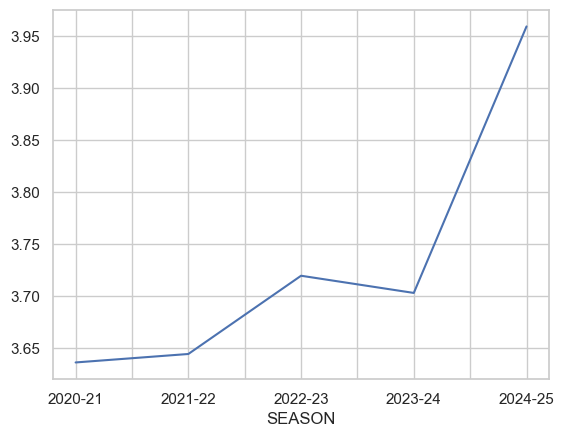

In [23]:
# ---------------- LINE PLOT OF 3 POINT ATTEMPTS ----------------
df[df['MIN'] > 15] \
    .groupby('SEASON')['FG3A'].mean().plot(kind='line')

In [24]:
# ---------------- BOX PLOT OF POINTS DISTRIBUTION ----------------
fig = px.box(
    df,
    x='SEASON',
    y='PTS',
    title="Points Distribution by Season"
)

fig.show()

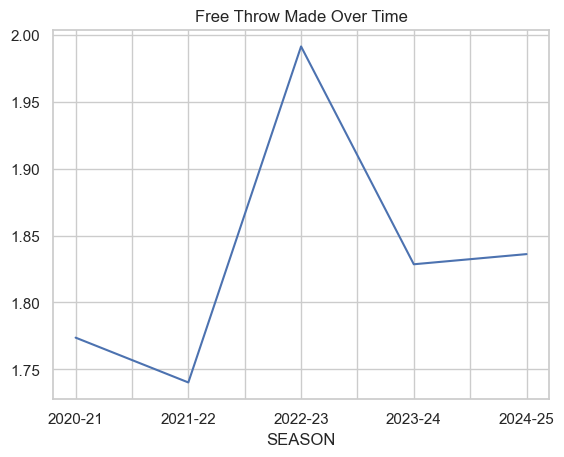

In [25]:
# ---------------- LINE PLOT OF FREE-THROWS MADE OVER TIME ----------------
df[df['MIN'] > 15] \
    .groupby('SEASON')['FTM'].mean() \
    .plot(kind='line')

plt.title("Free Throw Made Over Time")
plt.show()

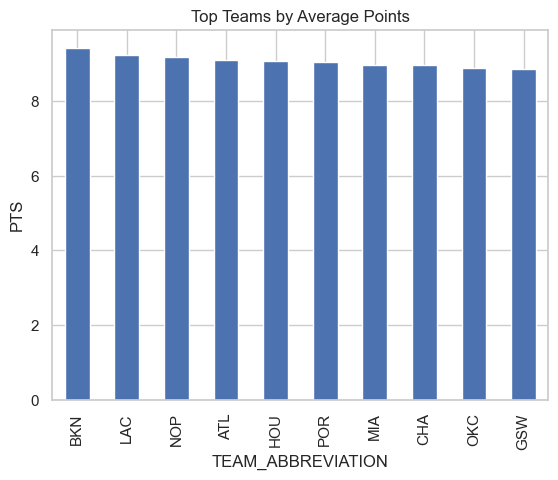

In [26]:
# ---------------- TOP TEAMS BY AVERAGE POINTS ----------------
df.groupby('TEAM_ABBREVIATION')['PTS'].mean() \
    .sort_values(ascending=False).head(10) \
    .plot(kind='bar')

plt.title("Top Teams by Average Points")
plt.ylabel("PTS")
plt.show()

In [27]:
# ---------------- SCATTER PLOT OF MINUTES AND PLUS/MINUS ----------------
fig = px.scatter(
    df,
    x='MIN',
    y='PLUS_MINUS',
    color='SEASON',
    hover_data=['PLAYER_NAME','TEAM_ABBREVIATION'],
    title="Minutes vs Points (Interactive)"
)

fig.show()

In [28]:
# ---------------- CORRELATION HEATMAP FOR PLUS/MINUS ----------------
corr = df[['PLUS_MINUS', 'PTS','REB','AST','MIN', 'TOV', 'SHOT_VOLUME']].corr()

fig = px.imshow(corr, text_auto=True, title="Correlation Heatmap")
fig.show()

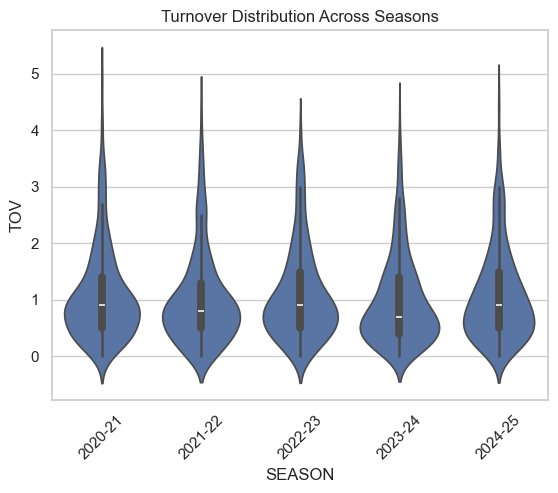

In [29]:
# ---------------- VIOLIN PLOT FOR TURNOVER DISTRIBUTION ----------------
plt.figure()
sns.violinplot(x='SEASON', y='TOV', data=df)
plt.xticks(rotation=45)
plt.title("Turnover Distribution Across Seasons")
plt.show()

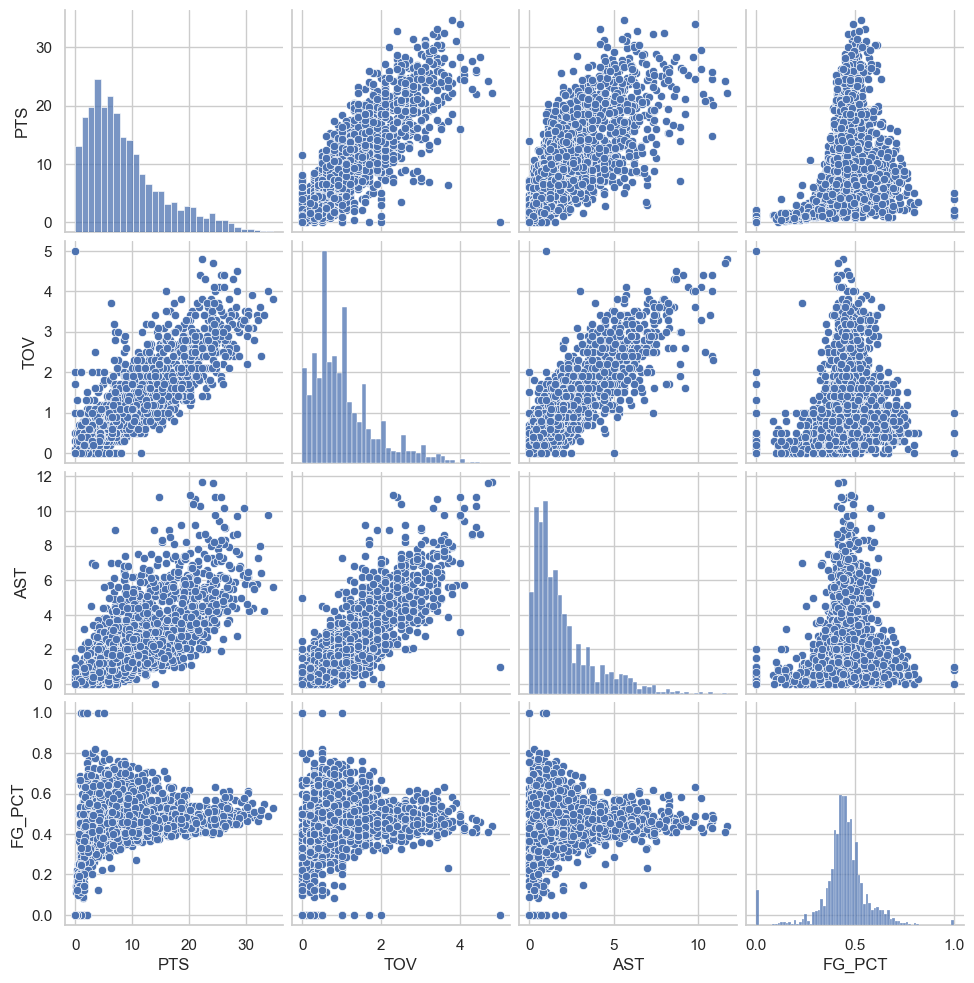

In [30]:
# ---------------- PAIR PLOT FOR KEY METRICS ----------------
sns.pairplot(df[['PTS','TOV','AST','FG_PCT']])

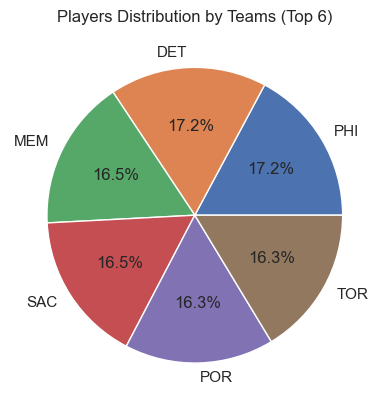

In [31]:
# ------------- PIE CHART FOR PLAYERS DISTRIBUTION BY TEAMS  -------------
df['TEAM_ABBREVIATION'].value_counts().head(6).plot(kind='pie', autopct='%1.1f%%')
plt.title("Players Distribution by Teams (Top 6)")
plt.ylabel("")
plt.show()

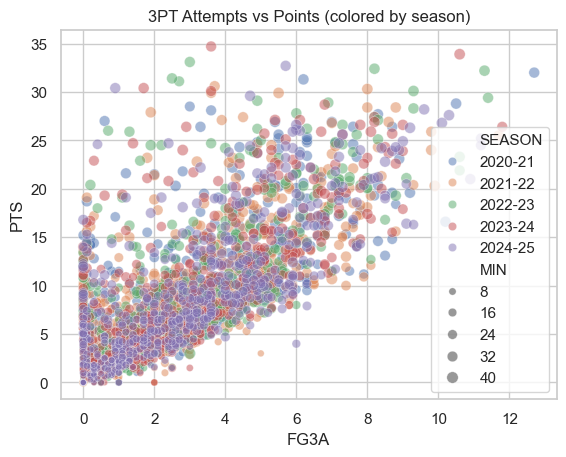

In [32]:
# --------------- SCATTER PLOT FOR 3PT ATTEMPTS AND POINTS ---------------
plt.figure()
sns.scatterplot(
    data=df,
    x='FG3A',
    y='PTS',
    hue='SEASON',
    size='MIN',
    alpha=0.5
)
plt.title("3PT Attempts vs Points (colored by season)")
plt.show()

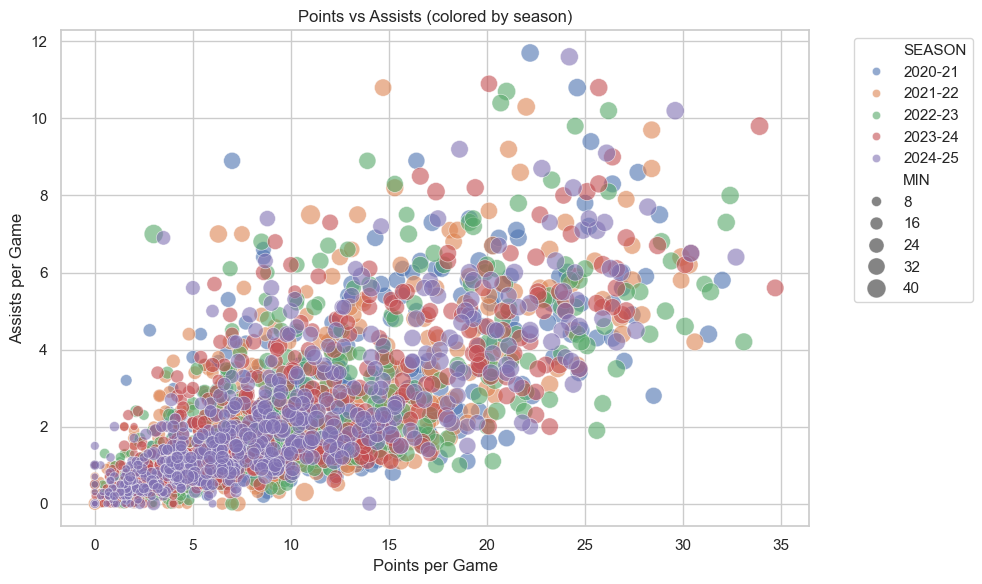

In [33]:
# ------------- SCATTER PLOT FOR ASSISTS AND POINT (PER GAME) -------------
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='PTS',
    y='AST',
    hue='SEASON',
    size='MIN',
    sizes=(20, 200),
    alpha=0.6,
)

plt.title("Points vs Assists (colored by season)")
plt.xlabel("Points per Game")
plt.ylabel("Assists per Game")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

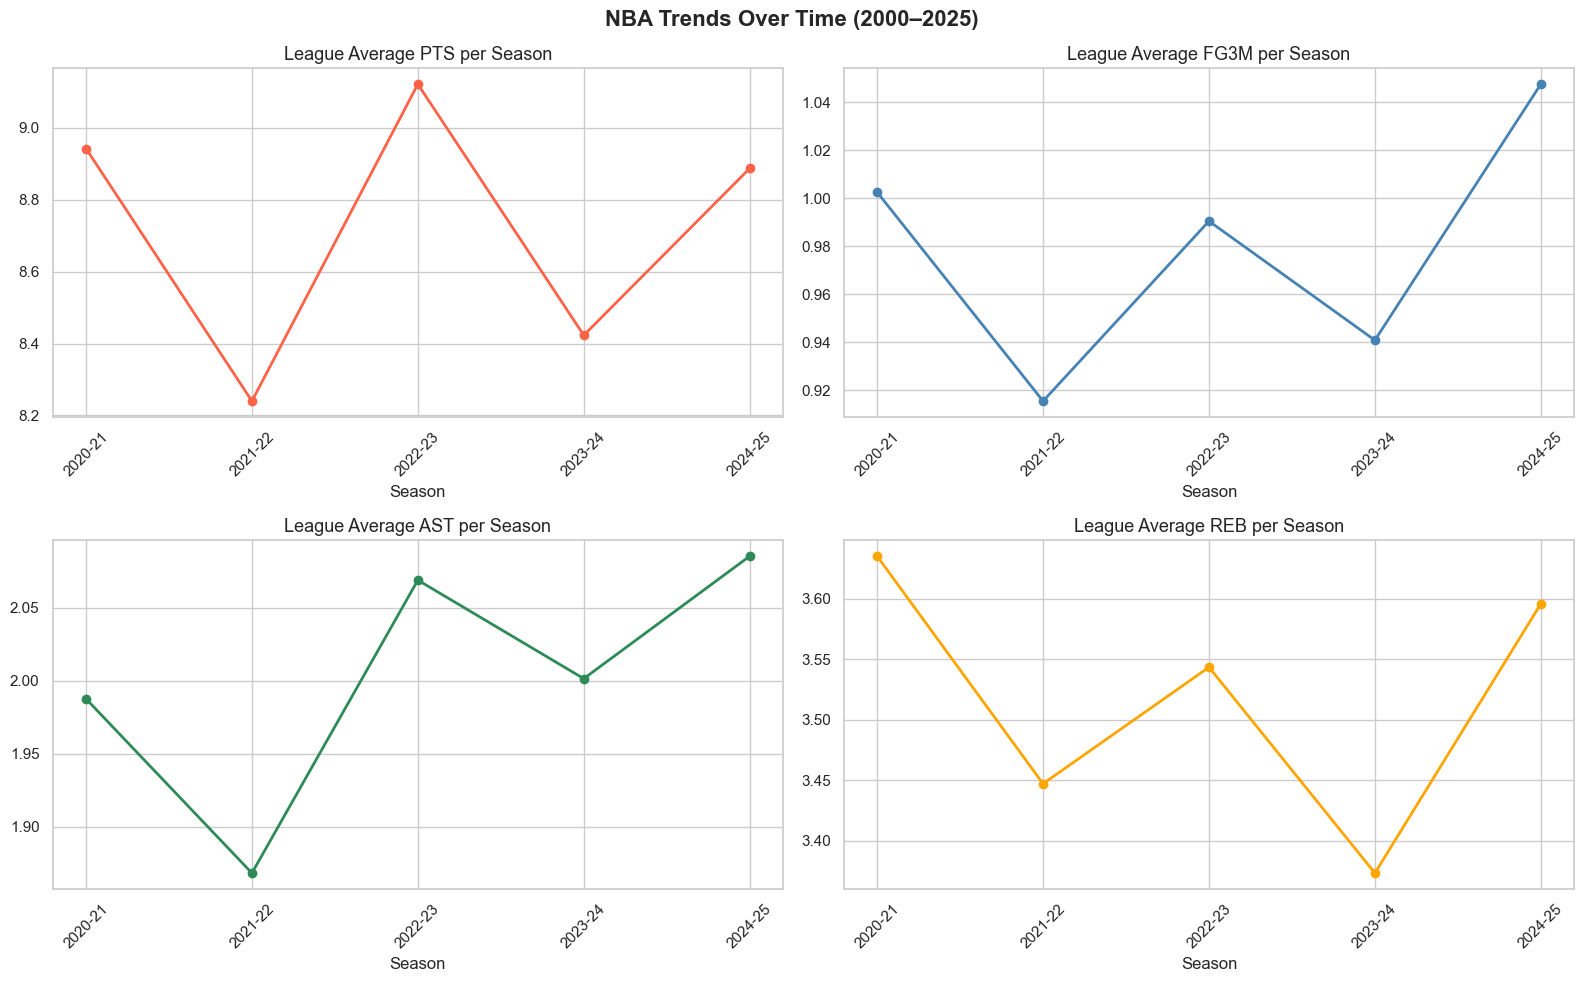

In [34]:
# ---------------- SUBPLOT GRID ----------------
season_avg = df.groupby('SEASON')[['PTS', 'FG3M', 'AST', 'REB']].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics = ['PTS', 'FG3M', 'AST', 'REB']
colors = ['tomato', 'steelblue', 'seagreen', 'orange']

for ax, metric, color in zip(axes.flatten(), metrics, colors):
    ax.plot(season_avg['SEASON'], season_avg[metric], marker='o', color=color, linewidth=2)
    ax.set_title(f'League Average {metric} per Season', fontsize=13)
    ax.set_xlabel('Season')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('NBA Trends Over Time (2000–2025)', fontsize=16, fontweight='bold')
plt.tight_layout()
os.makedirs('charts', exist_ok=True)
plt.savefig('charts/eda_trends.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# ---------------- PLAYERS WITH TOP PERFORMANCES ----------------
df_perf = df.copy()

top_perf = df_perf.groupby('PLAYER_NAME')[['DD2','TD3']].sum().reset_index()
top_perf = top_perf.sort_values('TD3', ascending=False).head(10)

fig = px.bar(
    top_perf,
    x='PLAYER_NAME',
    y=['DD2','TD3'],
    title="Top Players by Double-Doubles and Triple-Doubles",
    barmode='group'
)

fig.show()

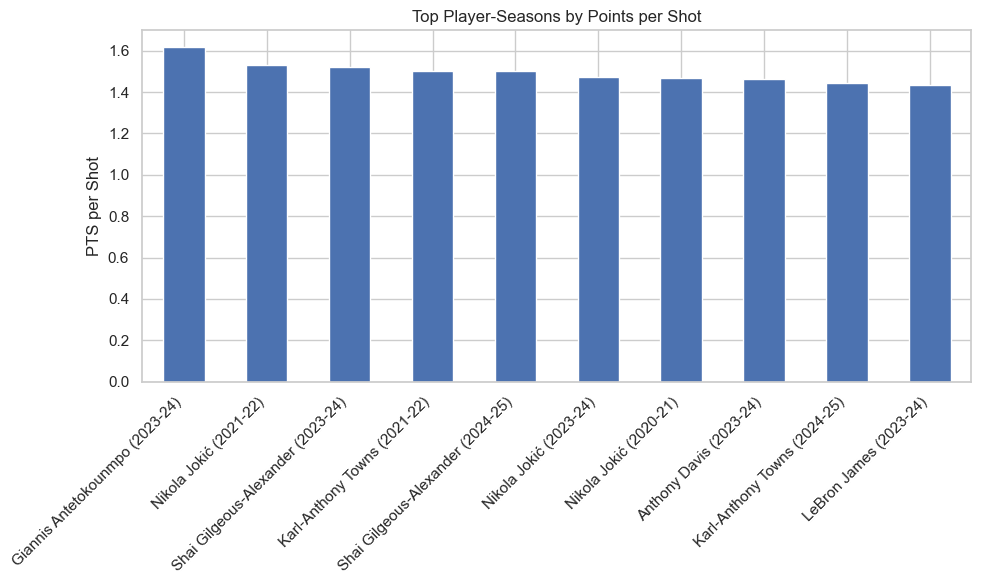

In [36]:
# -------------- PLAYERS WITH TOP PERFORMANCE IN ONE SEASON --------------
df_analysis = df.copy()

df_analysis = df_analysis[df_analysis['FGA'] > 0]

df_analysis['PTS_PER_SHOT'] = df_analysis['PTS'] / df_analysis['FGA']

df_filtered = df_analysis[(df_analysis['PTS'] > 20) & (df_analysis['GP'] > 70)]

top_eff = df_filtered.groupby(['PLAYER_NAME','SEASON']).agg({
    'PTS_PER_SHOT': 'mean',
    'PTS': 'mean',
    'FGA': 'mean'
}).sort_values('PTS_PER_SHOT', ascending=False).head(10)

top_eff.index = [f"{name} ({season})" for name, season in top_eff.index]

print(top_eff)

plt.figure(figsize=(10, 6))
top_eff['PTS_PER_SHOT'].plot(kind='bar')

plt.title("Top Player-Seasons by Points per Shot")
plt.ylabel("PTS per Shot")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [37]:
print(top_eff)

                                   PTS_PER_SHOT   PTS   FGA
Giannis Antetokounmpo (2023-24)        1.617021  30.4  18.8
Nikola Jokić (2021-22)                 1.531073  27.1  17.7
Shai Gilgeous-Alexander (2023-24)      1.520202  30.1  19.8
Karl-Anthony Towns (2021-22)           1.500000  24.6  16.4
Shai Gilgeous-Alexander (2024-25)      1.500000  32.7  21.8
Nikola Jokić (2023-24)                 1.474860  26.4  17.9
Nikola Jokić (2020-21)                 1.466667  26.4  18.0
Anthony Davis (2023-24)                1.461538  24.7  16.9
Karl-Anthony Towns (2024-25)           1.443787  24.4  16.9
LeBron James (2023-24)                 1.435754  25.7  17.9


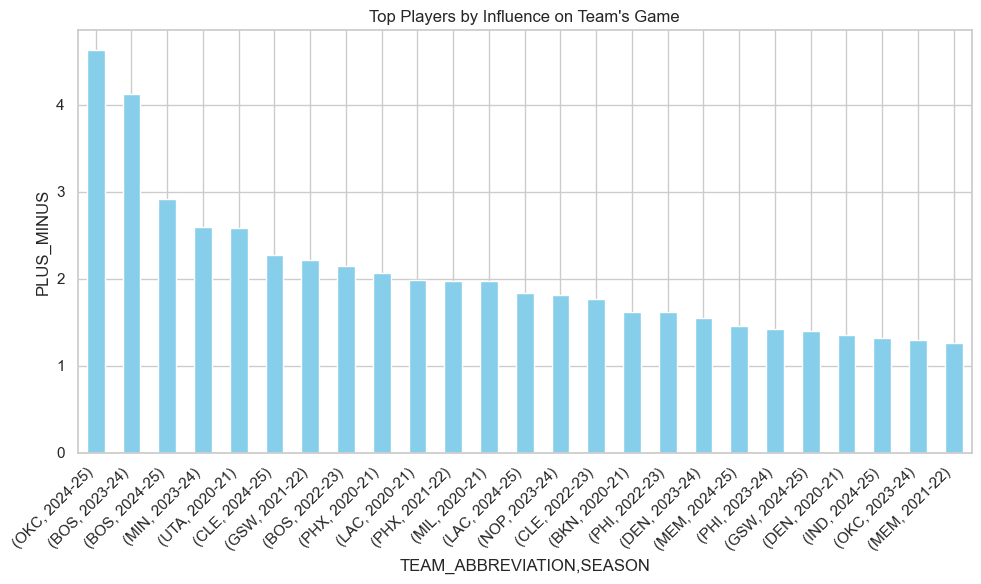

In [38]:
# ---------------- AVERAGE PLUS/MINUS OF TEAMS ----------------
print(df.groupby(['TEAM_ABBREVIATION', 'SEASON'])['PLUS_MINUS'].mean().sort_values(ascending=False))

plt.figure(figsize=(10, 6))
df.groupby(['TEAM_ABBREVIATION', 'SEASON'])['PLUS_MINUS'].mean().sort_values(ascending=False).head(25).plot(kind='bar', color='skyblue')

plt.title("Top Players by Influence on Team's Game")
plt.ylabel("PLUS_MINUS")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


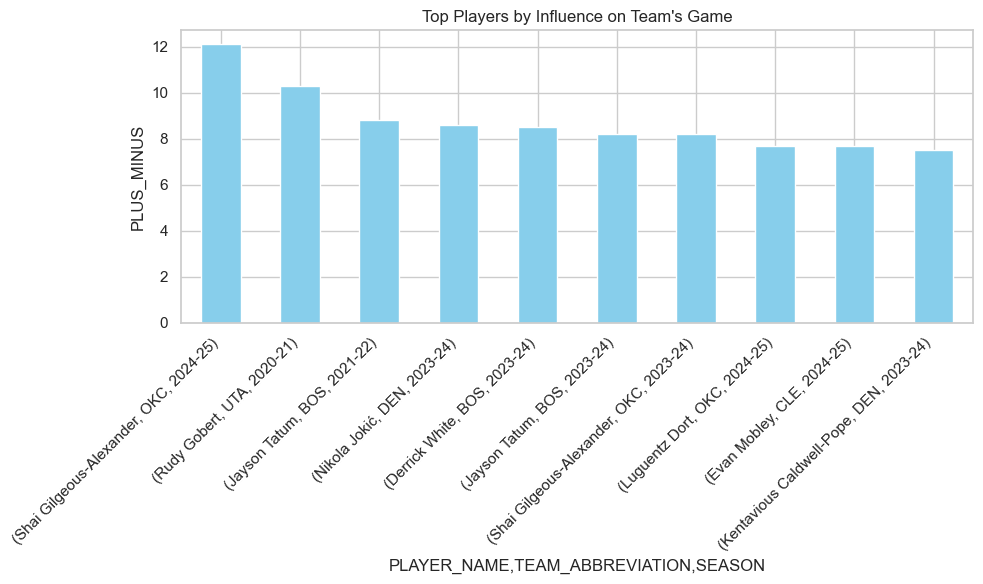

In [39]:
# --------------- PLAYERS WITH HIGH INFLUENCE IN ONE SEASON ---------------
df_top_players = df[df['GP'] > 70].copy()

top_players = df_top_players.sort_values(by='PLUS_MINUS', ascending=False).head(10)

top_players = top_players.set_index(['PLAYER_NAME', 'TEAM_ABBREVIATION', 'SEASON'])

plt.figure(figsize=(10, 6))
top_players['PLUS_MINUS'].plot(kind='bar', color='skyblue')

plt.title("Top Players by Influence on Team's Game")
plt.ylabel("PLUS_MINUS")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

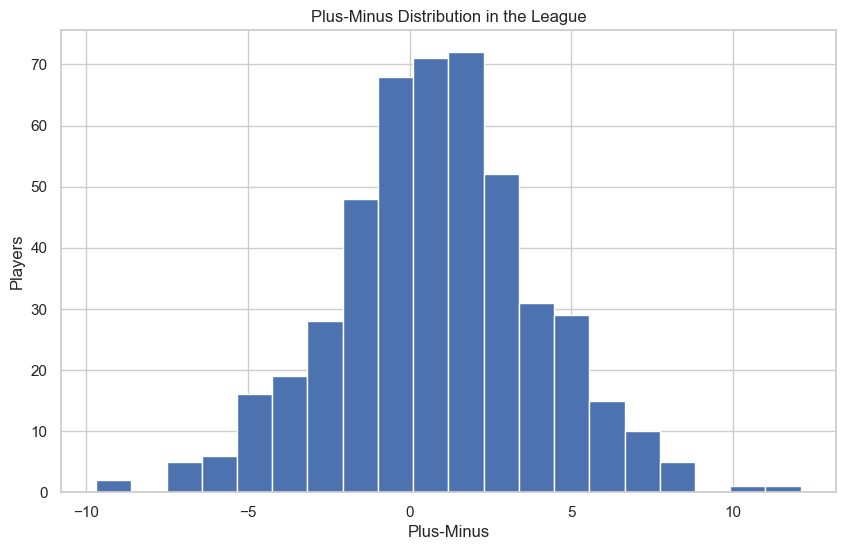

In [40]:
# ---------------- PLUS/MINUS DISTRIBUTION IN THE LEAGUE ----------------
plt.figure(figsize=(10, 6))
plt.hist(df_top_players['PLUS_MINUS'], bins=20)
plt.title("Plus-Minus Distribution in the League")
plt.xlabel("Plus-Minus")
plt.ylabel("Players")
plt.show()

In [57]:
# ------------ INTERACTIVE SCATTER PLOT SHOT VOLUME VS EFFICIENCY (ARCHETYPE MATRIX) -------------
df_plot = df[(df['GP'] > 60) & (df['FGA'] > 5)].copy()

x_mean = df_plot['SHOT_VOLUME'].mean()
y_mean = df_plot['EFF'].mean()

fig = px.scatter(
    df_plot,
    x='SHOT_VOLUME',
    y='EFF',
    color='SEASON',
    hover_data=['PLAYER_NAME', 'TEAM_ABBREVIATION'],
    title="Player Archetype Matrix: Shot Volume vs Efficiency",
    labels={'SHOT_VOLUME': 'Offensive Load (Shot Volume)', 'EFF': 'Impact Efficiency (EFF)'}
)

fig.add_vline(x=x_mean, line_dash="dash", line_color="gray", annotation_text="Avg Load")
fig.add_hline(y=y_mean, line_dash="dash", line_color="gray", annotation_text="Avg Eff")

fig.add_annotation(x=df_plot['SHOT_VOLUME'].max(), y=df_plot['EFF'].max(),
                   text="Offensive Engines", showarrow=False, font=dict(size=12, color="green"))
fig.add_annotation(x=df_plot['SHOT_VOLUME'].min(), y=df_plot['EFF'].max(),
                   text="Efficient Role Players", showarrow=False, font=dict(size=12, color="blue"))

fig.update_layout(showlegend=True)
fig.show()

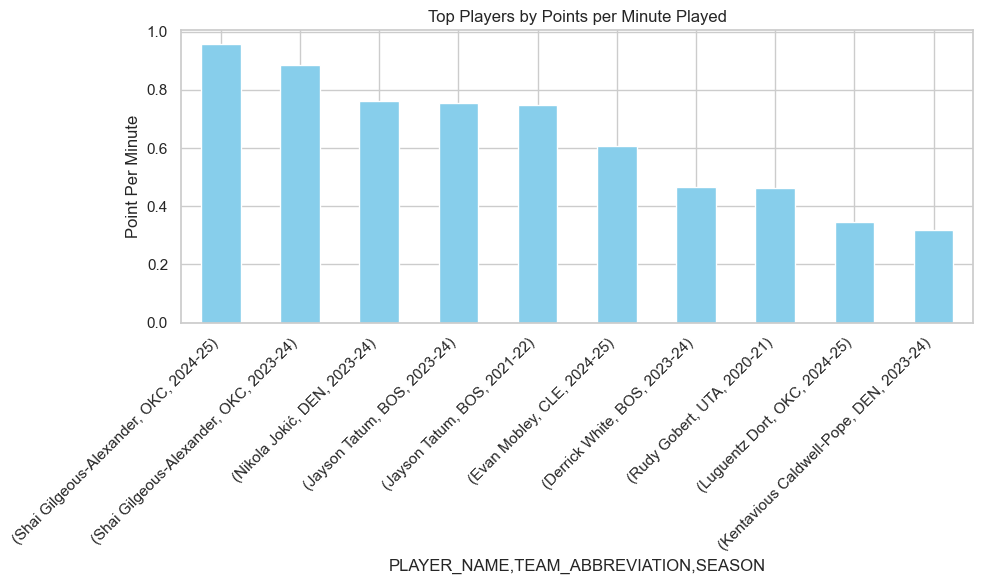

In [42]:
# ---------------- TOP EFFICIENT PLAYERS ----------------
plt.figure(figsize=(10, 6))
top_players['PTS_PER_MIN'].sort_values(ascending=False).plot(kind='bar', color='skyblue')

plt.title("Top Players by Points per Minute Played")
plt.ylabel("Point Per Minute")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [43]:
# -------------- CORRELATION BETWEEN SHOT_VOLUME AND POINTS --------------

fig = px.scatter(
    df[(df['GP'] > 60) & (df['FGA'] > 5)],
    x='PTS',
    y='SHOT_VOLUME',
    color='SEASON',
    hover_data=['PLAYER_NAME','TEAM_ABBREVIATION'],
    title="Shot Volume vs Points (Interactive)"
)

fig.show()

In [44]:
# ---------------- EFFICIENCY ANALYSIS ----------------

df_analysis['FG3P'] = df_analysis['FG3M'] / df_analysis['FG3A'] * 100
fig = px.scatter(
    df_analysis[(df_analysis['GP'] > 60) & (df_analysis['PTS'] > 30)],
    x="FG3A",
    y="FG3P",
    size="PTS",
    hover_name="PLAYER_NAME",
    color="PTS",

    hover_data={'SEASON': True},

    size_max=30,
    title="Efficiency analysis: 3PA Volume vs Success rate",
    labels={"FG3A": "3-point attempts (per game)", "FG3P": "3-point made percentage", "PTS": "Points", "SEASON": "Season"}
)

fig.show()

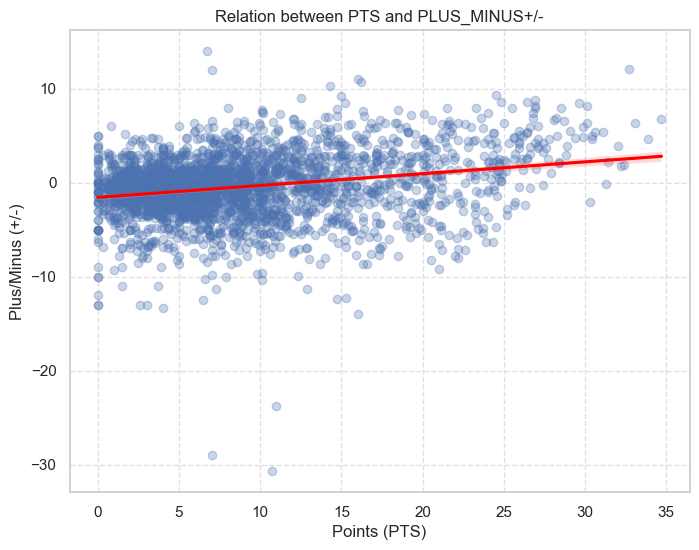

In [45]:
# ---------------- RELATION BETWEEN POINTS AND +/- ----------------
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df,
    x='PTS',
    y='PLUS_MINUS',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)
plt.title('Relation between PTS and PLUS_MINUS+/-')
plt.xlabel('Points (PTS)')
plt.ylabel('Plus/Minus (+/-)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

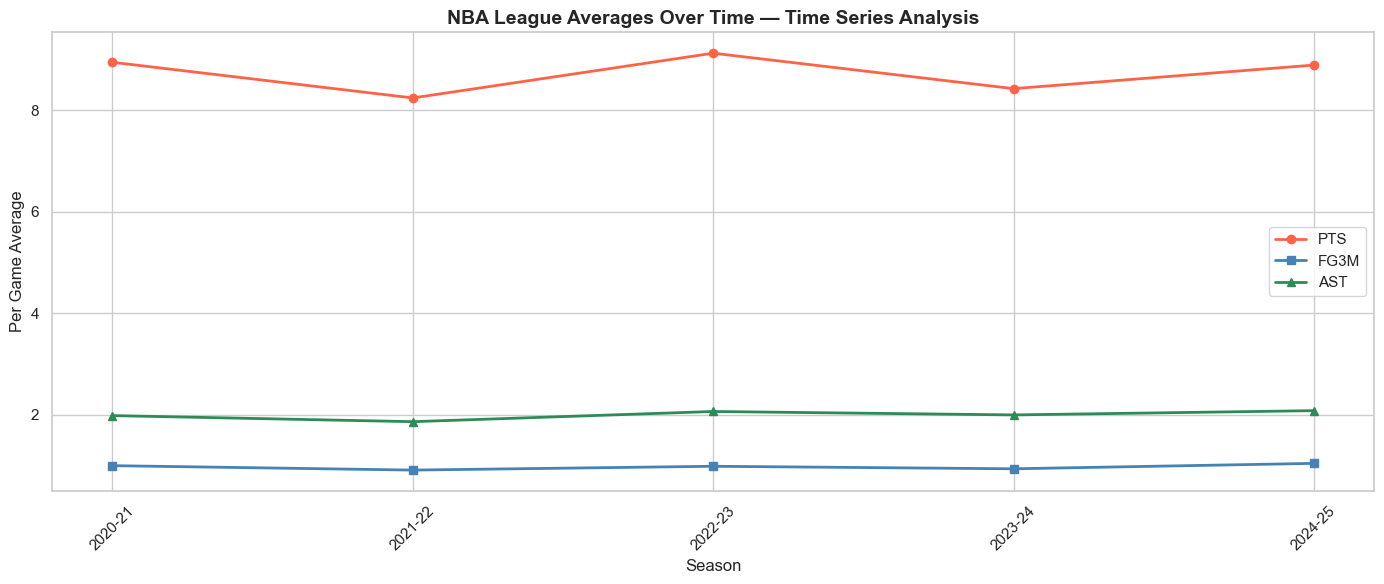

In [46]:
# ---------------- AVERAGE VALUES OVER TIME PERIOD (TREND) ----------------
ts_data = df.groupby('SEASON')[['PTS', 'FG3M', 'AST']].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(ts_data['SEASON'], ts_data['PTS'],  marker='o', label='PTS',  color='tomato',    linewidth=2)
ax.plot(ts_data['SEASON'], ts_data['FG3M'], marker='s', label='FG3M', color='steelblue', linewidth=2)
ax.plot(ts_data['SEASON'], ts_data['AST'],  marker='^', label='AST',  color='seagreen',  linewidth=2)
ax.set_title('NBA League Averages Over Time — Time Series Analysis', fontsize=14, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Per Game Average')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
os.makedirs('charts', exist_ok=True)
plt.savefig('charts/timeseries_trends.png', dpi=150, bbox_inches='tight')
plt.show()

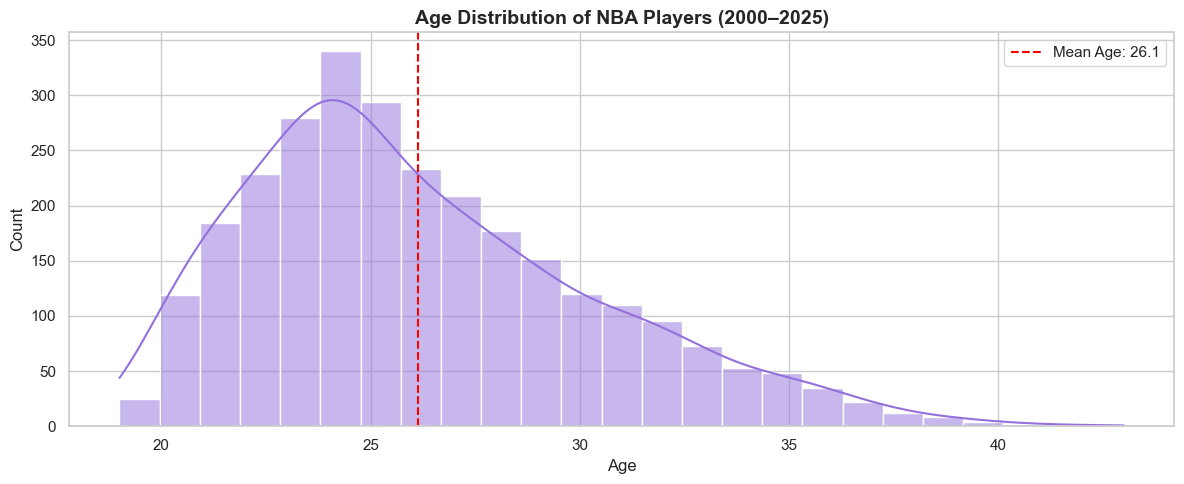

In [47]:
# ---------------- HISTOGRAM OF AGE DISTRIBUTION ----------------
plt.figure(figsize=(12, 5))
sns.histplot(df['AGE'].dropna(), bins=25, kde=True, color='mediumpurple')
plt.axvline(df['AGE'].mean(), color='red', linestyle='--', label=f'Mean Age: {df["AGE"].mean():.1f}')
plt.title('Age Distribution of NBA Players (2000–2025)', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.legend()
plt.tight_layout()
os.makedirs('charts', exist_ok=True)
plt.savefig('charts/eda_age_dist.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
    # ---------------- TESTING FIRST HYPOTHESIS (HIGH SCORERS HAVE BETTER WIN PERCENTAGE) ----------------
df_h = df[df['GP'] >= 20].dropna(subset=['PTS', 'W_PCT'])

high_scorers = df_h[df_h['PTS'] >= 15]['W_PCT']
low_scorers  = df_h[df_h['PTS'] < 15]['W_PCT']

t_stat, p_value = stats.ttest_ind(high_scorers, low_scorers)

print('=' * 55)
print('HYPOTHESIS 1: High Scorers vs Win Percentage')
print('=' * 55)
print(f'High scorers (>=15 PPG): n={len(high_scorers)}, mean W%={high_scorers.mean():.3f}')
print(f'Low scorers  (<15 PPG):  n={len(low_scorers)},  mean W%={low_scorers.mean():.3f}')
print(f't-statistic : {t_stat:.4f}')
print(f'p-value     : {p_value:.6f}')
print()
if p_value < 0.05:
    print('RESULT: Reject H0 — High scorers have significantly better W_PCT (p < 0.05)')
else:
    print('RESULT: Fail to reject H0 — No significant difference found')


HYPOTHESIS 1: High Scorers vs Win Percentage
High scorers (>=15 PPG): n=460, mean W%=0.519
Low scorers  (<15 PPG):  n=1759,  mean W%=0.490
t-statistic : 3.5914
p-value     : 0.000336

RESULT: Reject H0 — High scorers have significantly better W_PCT (p < 0.05)


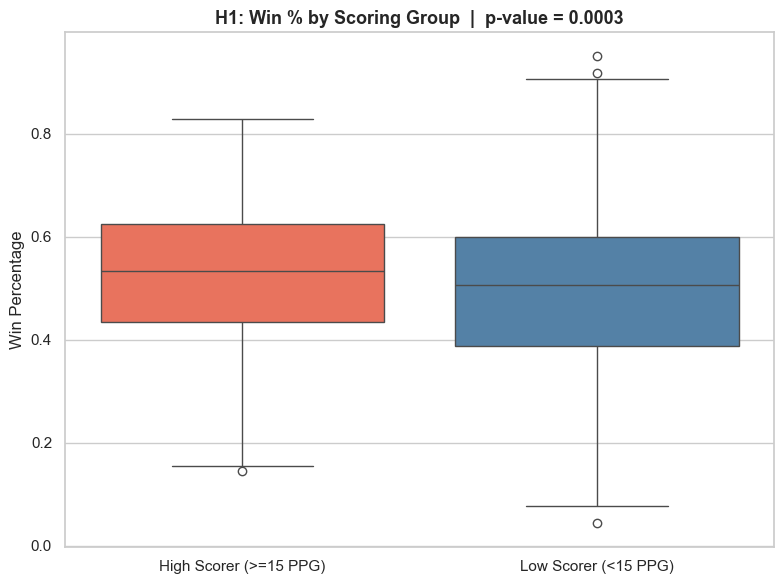

In [49]:
# ---------------- SUPPORTING PLOT FOR FIRST HYPOTHESIS ----------------
data_plot = pd.DataFrame({
    'W_PCT': pd.concat([high_scorers, low_scorers]),
    'Group': ['High Scorer (>=15 PPG)'] * len(high_scorers) + ['Low Scorer (<15 PPG)'] * len(low_scorers)
})

plt.figure(figsize=(8, 6))
sns.boxplot(x='Group', y='W_PCT', data=data_plot, palette=['tomato', 'steelblue'])
plt.title(f'H1: Win % by Scoring Group  |  p-value = {p_value:.4f}', fontsize=13, fontweight='bold')
plt.ylabel('Win Percentage')
plt.xlabel('')
plt.tight_layout()
os.makedirs('charts', exist_ok=True)
plt.savefig('charts/hyp1_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [50]:
# ---------------- TESTING SEC0ND HYPOTHESIS (IS THERE 3PT ERA IN NBA?) ----------------
early_era  = df[df['SEASON'].str[:4].astype(int) <= 2022]['FG3M'].dropna()
modern_era = df[df['SEASON'].str[:4].astype(int) >= 2023]['FG3M'].dropna()

t_stat2, p_value2 = stats.ttest_ind(modern_era, early_era)

print('=' * 55)
print('HYPOTHESIS 2: 3-Point Shooting — Early vs Modern Era')
print('=' * 55)
print(f'Early era  (2020-2022): n={len(early_era)},  mean FG3M={early_era.mean():.3f}')
print(f'Modern era (2023-2025): n={len(modern_era)}, mean FG3M={modern_era.mean():.3f}')
print(f't-statistic : {t_stat2:.4f}')
print(f'p-value     : {p_value2:.6f}')
print()
if p_value2 < 0.05:
    print('RESULT: Reject H0 — 3-point shooting significantly increased in modern era (p < 0.05)')
else:
    print('RESULT: Fail to reject H0 — No significant difference found')


data_h2 = pd.DataFrame({
    'FG3M': pd.concat([early_era, modern_era]),
    'Era': ['Early Era (2020-2022)'] * len(early_era) + ['Modern Era (2023-2025)'] * len(modern_era)
})


HYPOTHESIS 2: 3-Point Shooting — Early vs Modern Era
Early era  (2020-2022): n=1684,  mean FG3M=0.967
Modern era (2023-2025): n=1141, mean FG3M=0.994
t-statistic : 0.7862
p-value     : 0.431814

RESULT: Fail to reject H0 — No significant difference found


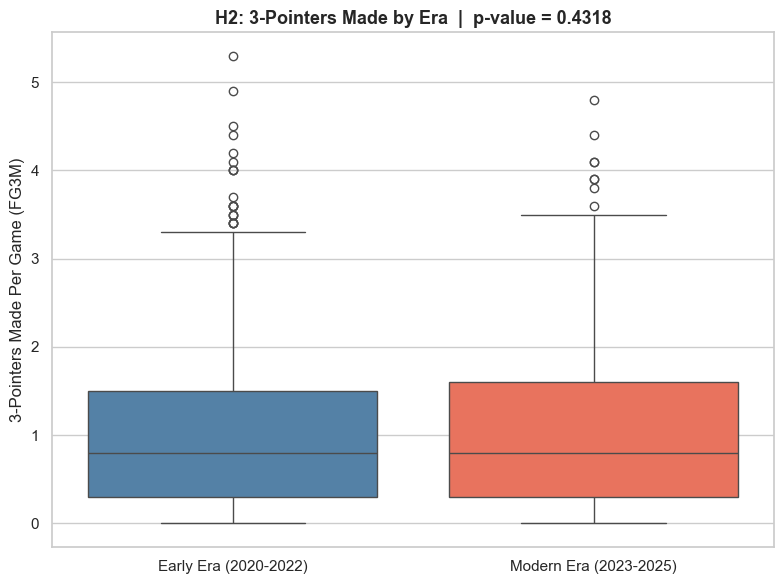

In [51]:
# ---------------- SUPPORTING PLOT FOR SECOND HYPOTHESIS ----------------
plt.figure(figsize=(8, 6))
sns.boxplot(x='Era', y='FG3M', data=data_h2, palette=['steelblue', 'tomato'])
plt.title(f'H2: 3-Pointers Made by Era  |  p-value = {p_value2:.4f}', fontsize=13, fontweight='bold')
plt.ylabel('3-Pointers Made Per Game (FG3M)')
plt.xlabel('')
plt.tight_layout()
os.makedirs('charts', exist_ok=True)
plt.savefig('charts/hyp2_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
# ---------------- TESTING THIRD HYPOTHESIS (RELATION BETWEEN SHOOTING EFFICIENCY AND +/-) ----------------
df_h3 = df[df['GP'] >= 20].dropna(subset=['FG_PCT', 'PLUS_MINUS'])

efficient   = df_h3[df_h3['FG_PCT'] >= 0.50]['PLUS_MINUS']
inefficient = df_h3[df_h3['FG_PCT'] < 0.50]['PLUS_MINUS']

t_stat3, p_value3 = stats.ttest_ind(efficient, inefficient)

print('=' * 55)
print('HYPOTHESIS 3: Shooting Efficiency vs Plus/Minus')
print('=' * 55)
print(f'Efficient   (FG% >=50%): n={len(efficient)},  mean +/-={efficient.mean():.3f}')
print(f'Inefficient (FG% <50%):  n={len(inefficient)}, mean +/-={inefficient.mean():.3f}')
print(f't-statistic : {t_stat3:.4f}')
print(f'p-value     : {p_value3:.6f}')
print()
if p_value3 < 0.05:
    print('RESULT: Reject H0 — Efficient shooters have significantly better +/- (p < 0.05)')
else:
    print('RESULT: Fail to reject H0 — No significant difference found')

data_h3 = pd.DataFrame({
    'PLUS_MINUS': pd.concat([efficient, inefficient]),
    'Group': ['Efficient (FG% >=50%)'] * len(efficient) + ['Inefficient (FG% <50%)'] * len(inefficient)
})

HYPOTHESIS 3: Shooting Efficiency vs Plus/Minus
Efficient   (FG% >=50%): n=555,  mean +/-=0.441
Inefficient (FG% <50%):  n=1664, mean +/-=-0.376
t-statistic : 5.5255
p-value     : 0.000000

RESULT: Reject H0 — Efficient shooters have significantly better +/- (p < 0.05)


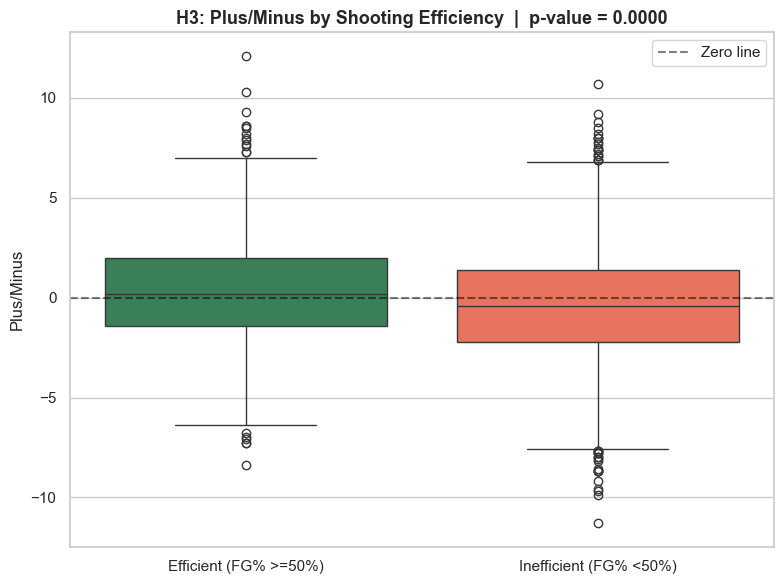

In [53]:
# ---------------- SUPPORTING PLOT FOR THIRD HYPOTHESIS ----------------
plt.figure(figsize=(8, 6))
sns.boxplot(x='Group', y='PLUS_MINUS', data=data_h3, palette=['seagreen', 'tomato'])
plt.axhline(0, color='black', linestyle='--', alpha=0.5, label='Zero line')
plt.title(f'H3: Plus/Minus by Shooting Efficiency  |  p-value = {p_value3:.4f}', fontsize=13, fontweight='bold')
plt.ylabel('Plus/Minus')
plt.xlabel('')
plt.legend()
plt.tight_layout()
os.makedirs('charts', exist_ok=True)
plt.savefig('charts/hyp3_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()